In [1]:
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt



In [2]:
DATA = Path("../data")

dataset = pd.read_csv(DATA / 'loan_data.csv')

In [3]:
df = dataset.copy()

In [4]:
df['Loan_ID'].value_counts()

Loan_ID
LP001002    1
LP001003    1
LP001005    1
LP001006    1
LP001008    1
           ..
LP002978    1
LP002979    1
LP002983    1
LP002984    1
LP002990    1
Name: count, Length: 614, dtype: int64

In [5]:
df = df.drop(columns = ['Loan_ID'])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    str    
 1   Married            611 non-null    str    
 2   Dependents         599 non-null    str    
 3   Education          614 non-null    str    
 4   Self_Employed      582 non-null    str    
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    str    
 11  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 73.8 KB


In [7]:
columns = ['Gender', 'Married', 'Self_Employed', 'Education',
           'Loan_Status']

df['Gender'].value_counts().index[1]

'Female'

In [8]:
for column in columns: 
    df[column] = df[column].map({df[column].value_counts().index[0]: 0,
                                df[column].value_counts().index[1]: 1})

In [9]:
df['Gender'].value_counts()

Gender
0.0    489
1.0    112
Name: count, dtype: int64

In [10]:
df['Married'].value_counts()

Married
0.0    398
1.0    213
Name: count, dtype: int64

In [12]:
df['Loan_Status'].value_counts()

Loan_Status
0    422
1    192
Name: count, dtype: int64

In [14]:
df['Dependents'].value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

In [15]:
df['Dependents'] = df['Dependents'].replace("3+", "3").astype(float)

In [16]:
df['Dependents'].value_counts()

Dependents
0.0    345
1.0    102
2.0    101
3.0     51
Name: count, dtype: int64

In [17]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [18]:
df['Property_Area'].value_counts()

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

In [19]:
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True, dtype = int)


In [20]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,0.0,1.0,0.0,0,0.0,5849,0.0,NaN,360.0,1.0,0,0,1
1,0.0,0.0,1.0,0,0.0,4583,1508.0,128.0,360.0,1.0,1,0,0
2,0.0,0.0,0.0,0,1.0,3000,0.0,66.0,360.0,1.0,0,0,1
3,0.0,0.0,0.0,1,0.0,2583,2358.0,120.0,360.0,1.0,0,0,1
4,0.0,1.0,0.0,0,0.0,6000,0.0,141.0,360.0,1.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,1.0,1.0,0.0,0,0.0,2900,0.0,71.0,360.0,1.0,0,0,0
610,0.0,0.0,3.0,0,0.0,4106,0.0,40.0,180.0,1.0,0,0,0
611,0.0,0.0,1.0,0,0.0,8072,240.0,253.0,360.0,1.0,0,0,1
612,0.0,0.0,2.0,0,0.0,7583,0.0,187.0,360.0,1.0,0,0,1


In [21]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status',
       'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='str')

## Feature Engineering

In [22]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df = df.drop(columns = ['ApplicantIncome', 'CoapplicantIncome'])

In [23]:
df.shape

(614, 12)

In [24]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status',
       'Property_Area_Semiurban', 'Property_Area_Urban', 'Total_Income'],
      dtype='str')

In [25]:
income_before = df['Total_Income']

In [26]:
print("Rows before removing the outliers: ", len(df))

Rows before removing the outliers:  614


In [28]:
df['Total_Income'].min()

np.float64(1442.0)

In [29]:
df['Total_Income'].max()

np.float64(81000.0)

In [30]:
df['Total_Income'].std()

np.float64(6458.66387219434)

In [31]:
df['Total_Income'].mean()

np.float64(7024.705081414722)

{'whiskers': [<matplotlib.lines.Line2D at 0x21907c77350>,
 'caps': [<matplotlib.lines.Line2D at 0x21907c77530>,
 'boxes': [<matplotlib.lines.Line2D at 0x2190683c200>],
 'medians': [<matplotlib.lines.Line2D at 0x21907c778f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x21907c77b90>],
 'means': []}

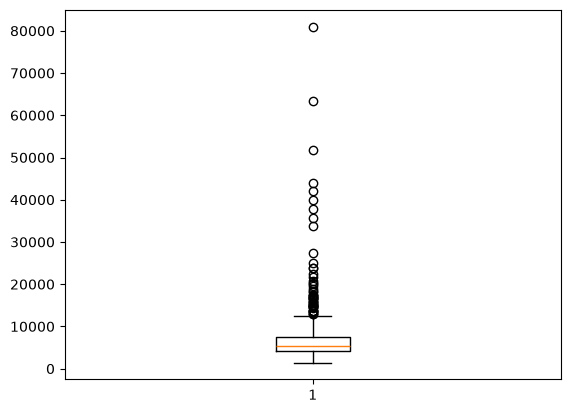

In [32]:
plt.boxplot(df['Total_Income'])

In [33]:
df = df[df['Total_Income'] < 25000]

In [35]:
print("No of rows after removing the outliers: ", df.shape[0])

No of rows after removing the outliers:  604


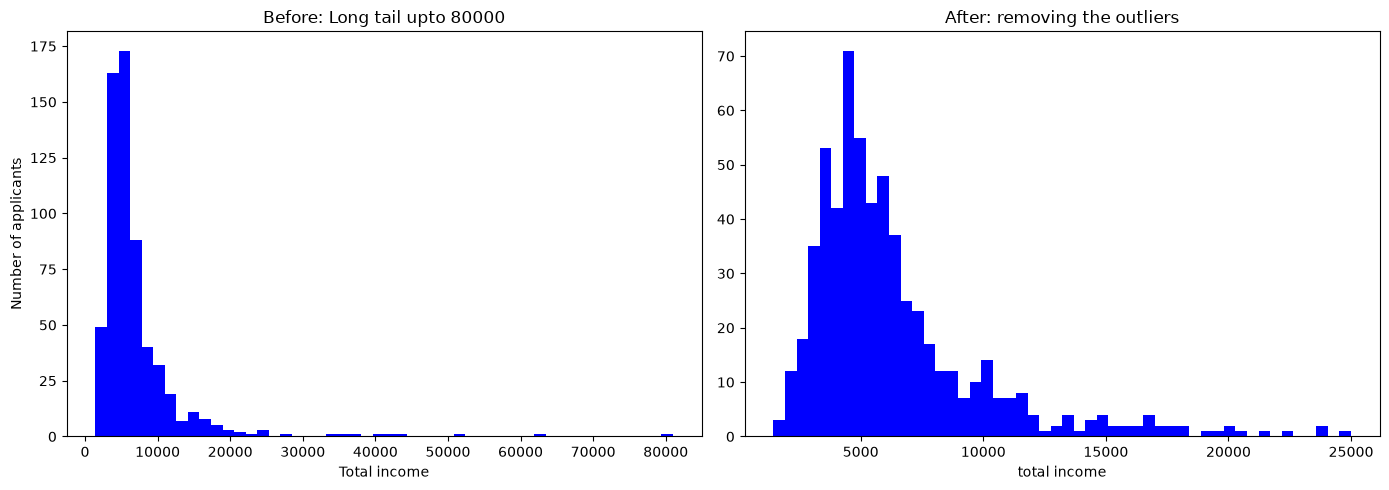

In [36]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.hist(income_before, bins = 50, color = 'blue')
plt.title("Before: Long tail upto 80000")
plt.xlabel("Total income")
plt.ylabel("Number of applicants")

plt.subplot(1,2,2)
plt.hist(df['Total_Income'], bins = 50, color = 'blue')
plt.title("After: removing the outliers")
plt.xlabel("total income")

plt.tight_layout()
plt.show()

## Plot correlation heatmap

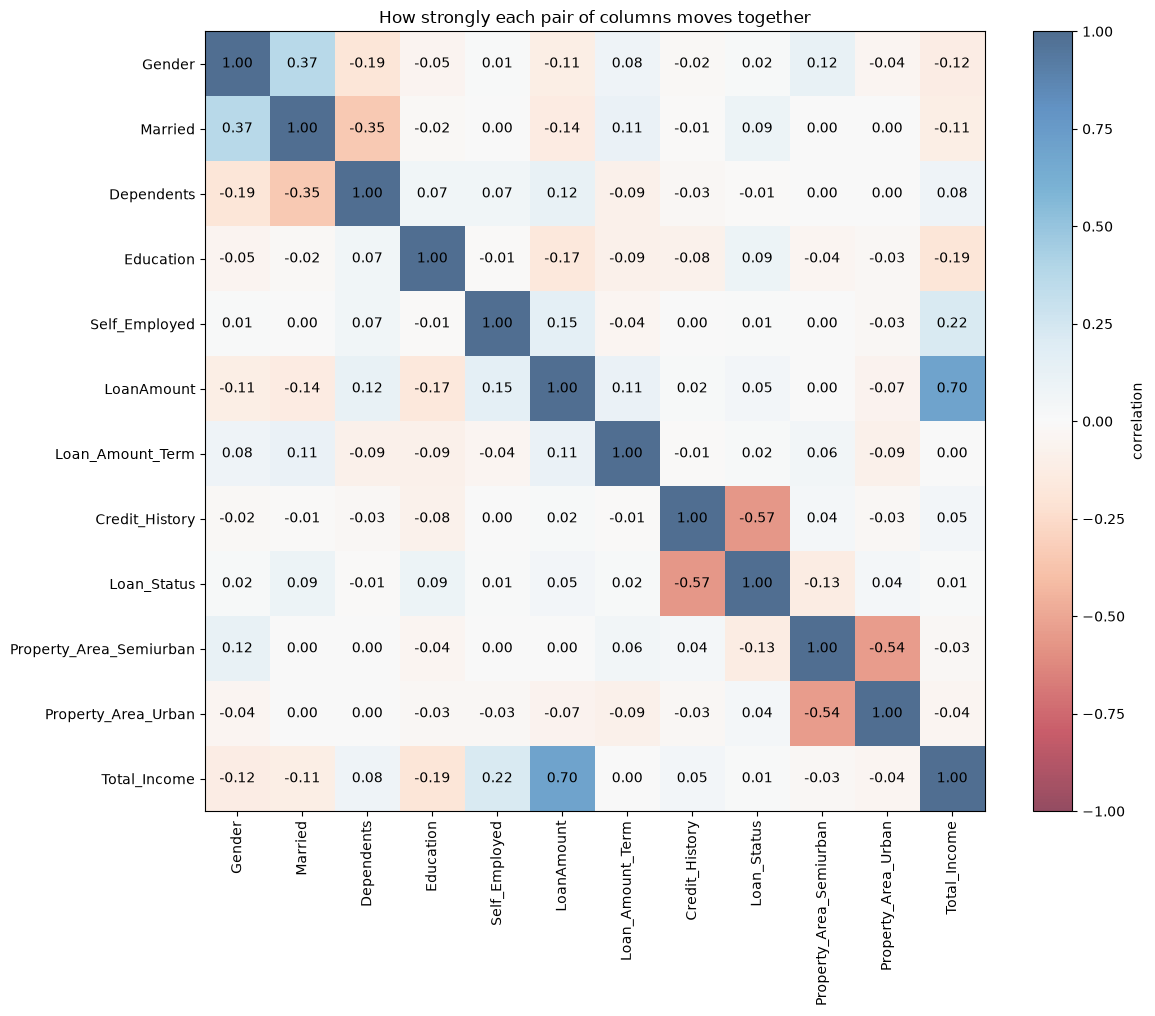

In [37]:
corr = df.corr().round(2) + 0

size = len(corr)

plt.figure(figsize=(12,10))
plt.imshow(corr, cmap="RdBu", vmin = -1, vmax = 1, alpha = 0.7)
plt.colorbar(label = "correlation")
plt.xticks(range(size), corr.columns, rotation = 90)
plt.yticks(range(size), corr.columns)
for row in range(size):
    for col in range(size):
        number = f"{corr.iloc[row, col]:.2f}"
        plt.text(col, row, number, ha='center', va='center', fontsize=10)

plt.title("How strongly each pair of columns moves together")
plt.tight_layout()
plt.show()

In [38]:
print(df.head(3).T)

                              0       1       2
Gender                      0.0     0.0     0.0
Married                     1.0     0.0     0.0
Dependents                  0.0     1.0     0.0
Education                   0.0     0.0     0.0
Self_Employed               0.0     0.0     1.0
LoanAmount                  NaN   128.0    66.0
Loan_Amount_Term          360.0   360.0   360.0
Credit_History              1.0     1.0     1.0
Loan_Status                 0.0     1.0     0.0
Property_Area_Semiurban     0.0     0.0     0.0
Property_Area_Urban         1.0     0.0     1.0
Total_Income             5849.0  6091.0  3000.0


In [39]:
df.isna().sum()

Gender                     12
Married                     3
Dependents                 15
Education                   0
Self_Employed              30
LoanAmount                 22
Loan_Amount_Term           14
Credit_History             48
Loan_Status                 0
Property_Area_Semiurban     0
Property_Area_Urban         0
Total_Income                0
dtype: int64